In [96]:
import pandas as pd
import numpy as np
# from matplotlib.pyplot import plot
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
# train_df = pd.read_csv('train.tsv', sep='\t')
# test_df = pd.read_csv('test.tsv', sep='\t')

# Unnamedが出てしまうので、index_col=0にする。→Unnamedがindexになる。
train_df = pd.read_csv('train.tsv', sep='\t', index_col=0)
test_df = pd.read_csv('test.tsv', sep='\t', index_col=0)

In [98]:
train_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
id,,,,,,,,,
0,29.0,4,135.0,84.00,2525.0,16.0,82,1,dodge aries se
3,31.9,4,89.0,71.00,1925.0,14.0,79,2,vw rabbit custom
9,19.0,6,156.0,108.0,2930.0,15.5,76,3,toyota mark ii
11,28.0,4,90.0,75.00,2125.0,14.5,74,1,dodge colt
13,37.7,4,89.0,62.00,2050.0,17.3,81,3,toyota tercel


In [99]:
test_df.head()

,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
id,,,,,,,,
1,6,145.0,76.00,3160.0,19.6,81,2,volvo diesel
2,6,250.0,98.00,3525.0,19.0,77,1,ford granada
4,4,119.0,92.00,2434.0,15.0,80,3,datsun 510 hatchback
5,6,258.0,110.0,2962.0,13.5,71,1,amc hornet sportabout (sw)
6,4,97.0,88.00,2100.0,16.5,72,3,toyota corolla 1600 (sw)


In [100]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           199 non-null    float64
 1   cylinders     199 non-null    int64  
 2   displacement  199 non-null    float64
 3   horsepower    199 non-null    object 
 4   weight        199 non-null    float64
 5   acceleration  199 non-null    float64
 6   model year    199 non-null    int64  
 7   origin        199 non-null    int64  
 8   car name      199 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 15.5+ KB


In [101]:
train_df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [102]:
train_df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')

In [103]:
cat_features = ['horsepower', 'car name']
num_features = ['mpg', 'cylinders', 'displacement', 'weight',
       'acceleration', 'model year', 'origin']

In [104]:
# for feature in cat_features:
#     print(f'{feature} : {train_df[feature].nunique()}') # dfのfeatureのカラムのnunique(何種類か)を確認
#     print(train_df[feature].unique()) # そのユニーク値を(実際のユニークな値)確認
#     print('='*20)

# 気付き
- horsepowerは「？」が入っており、categorycalになっているが、実態はNumericな特徴量

In [105]:
train_df['horsepower'].sample(10)

id
11     75.00
50     85.00
187    88.00
174    130.0
13     62.00
325    180.0
252    54.00
315    61.00
188    96.00
240    95.00
Name: horsepower, dtype: object

In [106]:
# Replace '?' with NaN
train_df['horsepower'].replace('?', np.nan, inplace=True)

# Convert the column to float
train_df['horsepower'] = train_df['horsepower'].astype(float) # 'float64')

/var/folders/7h/pvrr2skj31l3k_w_t4bj4q280000gn/T/ipykernel_67006/2195227720.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['horsepower'].replace('?', np.nan, inplace=True)


In [107]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           199 non-null    float64
 1   cylinders     199 non-null    int64  
 2   displacement  199 non-null    float64
 3   horsepower    195 non-null    float64
 4   weight        199 non-null    float64
 5   acceleration  199 non-null    float64
 6   model year    199 non-null    int64  
 7   origin        199 non-null    int64  
 8   car name      199 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 15.5+ KB


In [108]:
# scikit-learnライブラリからtrain_test_split関数をインポート
from sklearn.model_selection import train_test_split

# idの削除
# train_df = train_df.drop(columns=['id'], axis=1)

# 欠損値を含む行の削除
train_df = train_df.dropna()

# 説明変数と目的変数の取り出し
y = train_df['mpg']
X = train_df[['cylinders','displacement','horsepower','weight','acceleration','origin']] # 'model year','origin', 'car name']]

# X = pd.get_dummies(X) # 各説明変数のダミー変数化

# 学習データと評価データに分割
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=32, test_size=0.2)

# X_trainとX_testから行数を取り出し、それぞれ変数X_train_line, X_test_lineに代入し、表示
X_train_line = X_train.shape[0]
X_test_line = X_test.shape[0]
print(X_train_line)
print(X_test_line)

156
39


In [109]:
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import mean_squared_error as MSE

# モデルの箱を準備
lr = LR()

# モデルを学習
lr.fit(X_train, y_train)

# モデルから予測結果を求める
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

# 学習データのRMSEの算出
mse_train = MSE(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)

# 評価データのRMSEの算出
mse_test = MSE(y_test,y_pred_test)
rmse_test = np.sqrt(mse_test)

# 学習および評価データに対するRMSEを表示
print(rmse_train)
print(rmse_test)

3.7955089273463627
5.191634634719943


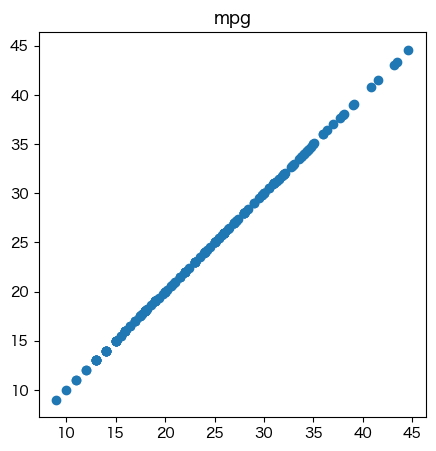

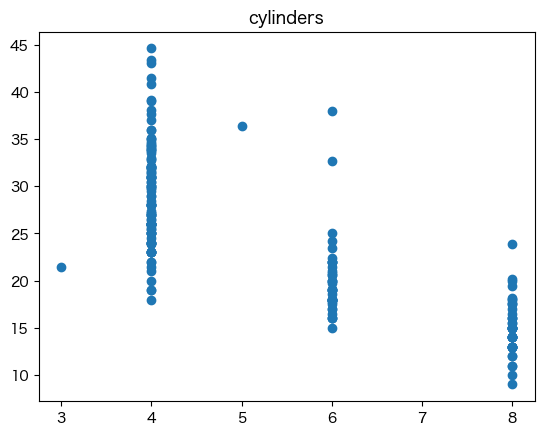

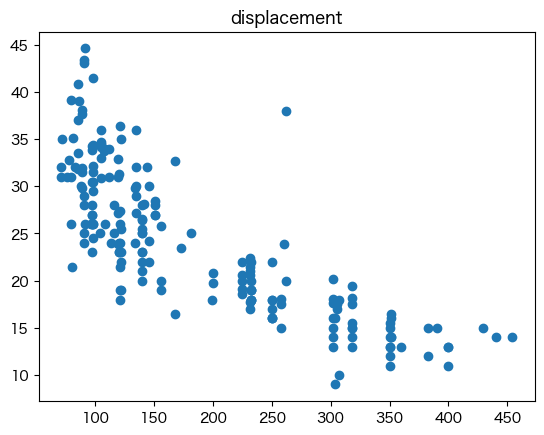

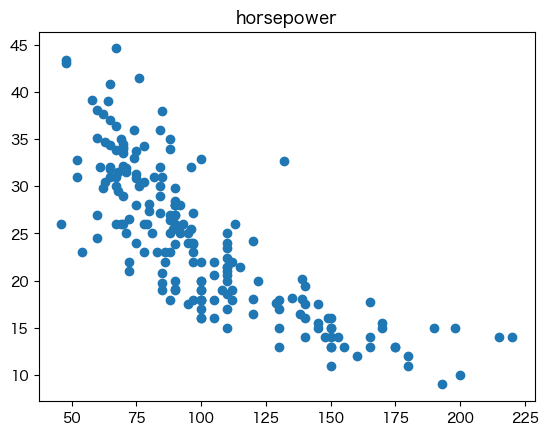

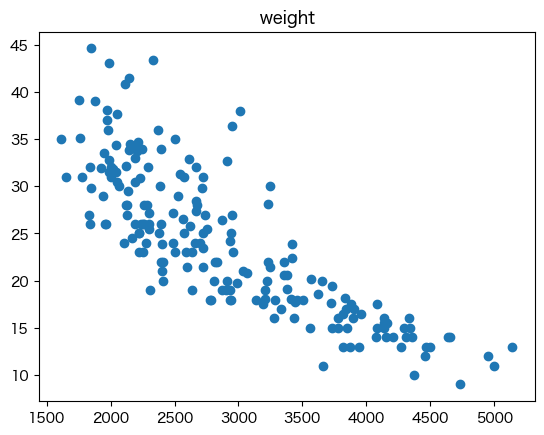

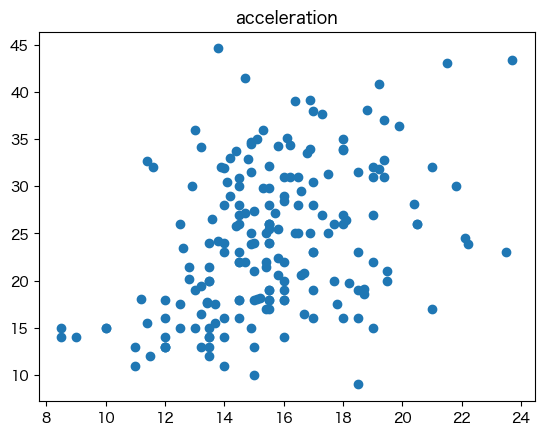

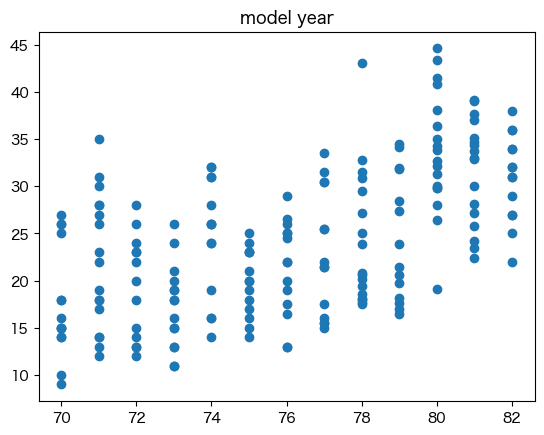

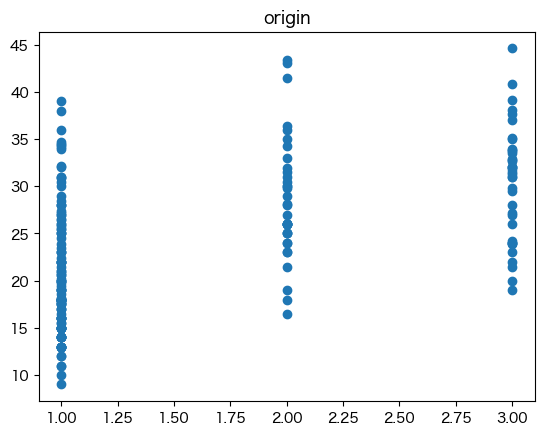

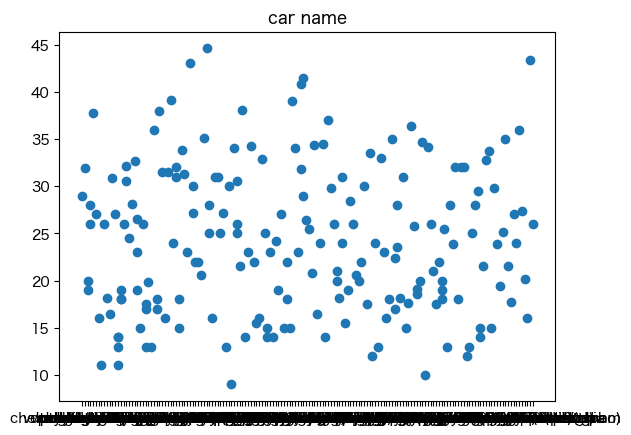

In [110]:
plt.figure(figsize=(5, 5))
for feature in train_df.columns:
    plt.title(feature)
    plt.scatter(data=train_df, x=feature, y='mpg')
    plt.show()

In [111]:
# 対数化
train_df['displacement_log']= np.log(train_df['displacement'])
train_df['horsepower_log']= np.log(train_df['horsepower'])
train_df['weight_log']= np.log(train_df['weight'])

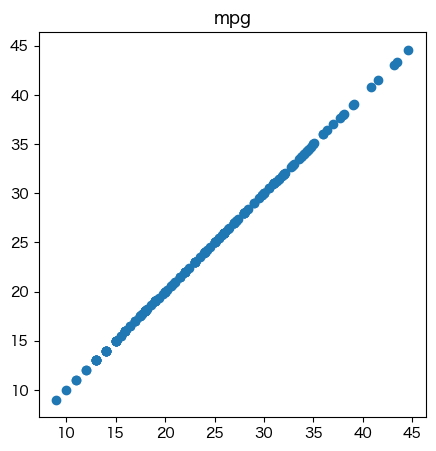

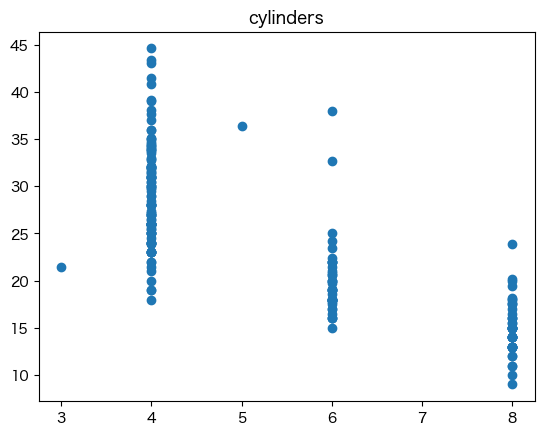

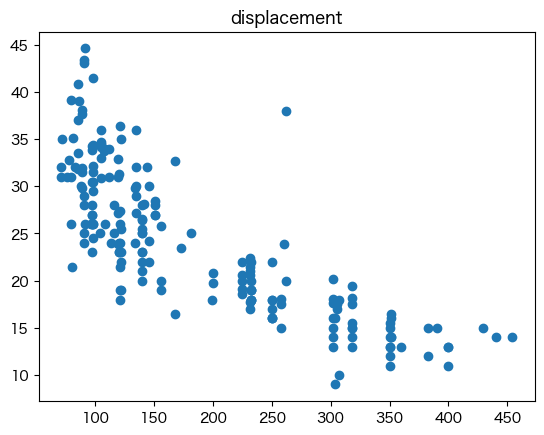

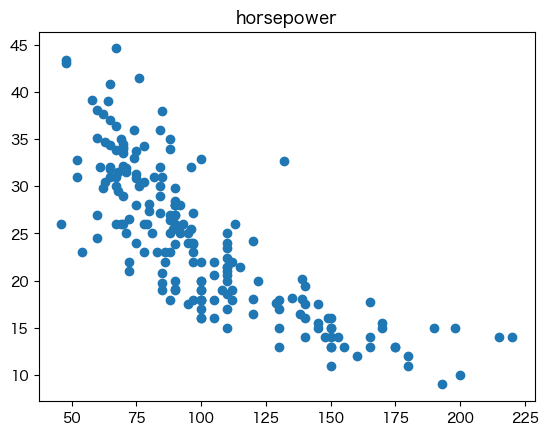

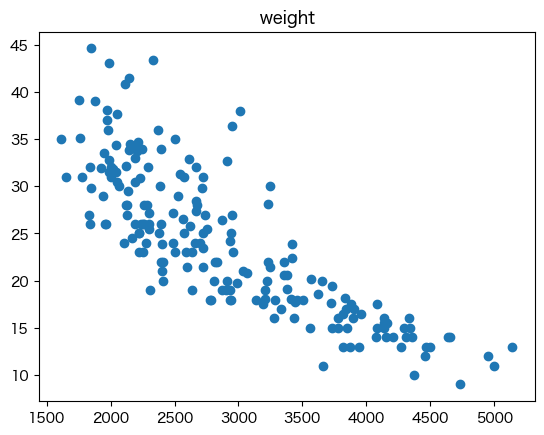

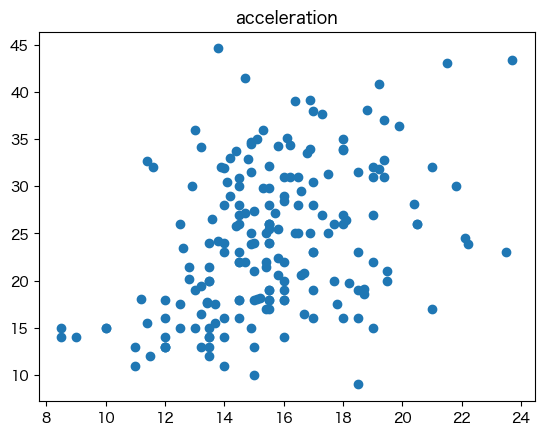

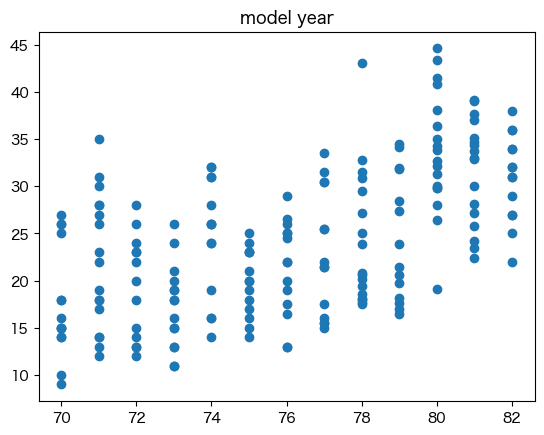

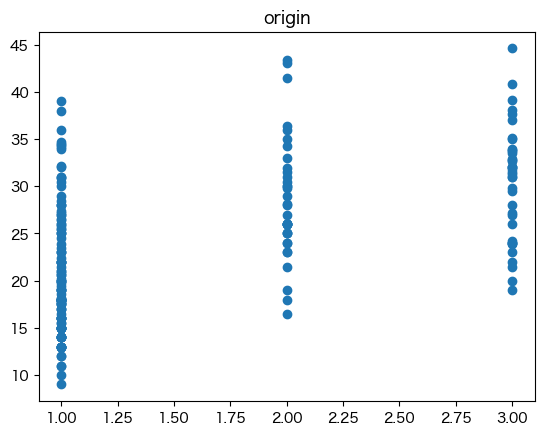

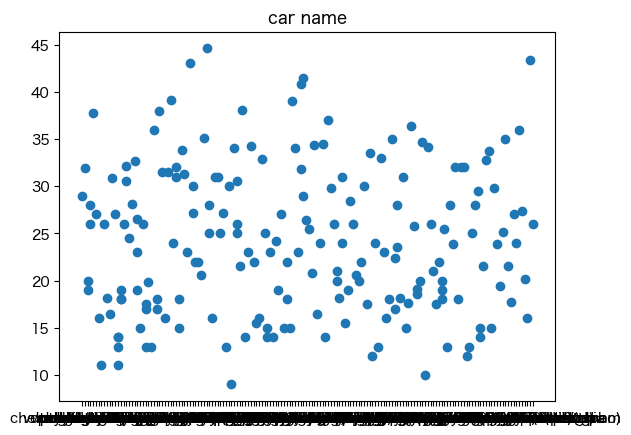

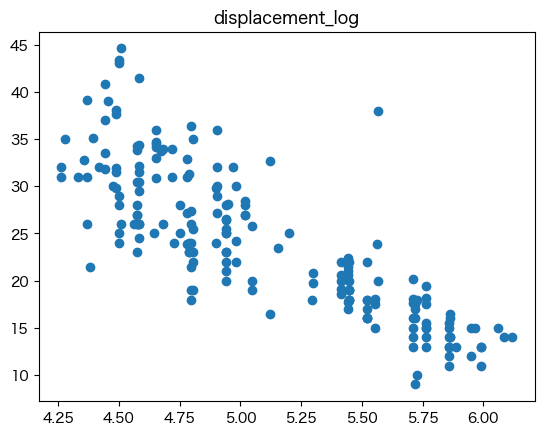

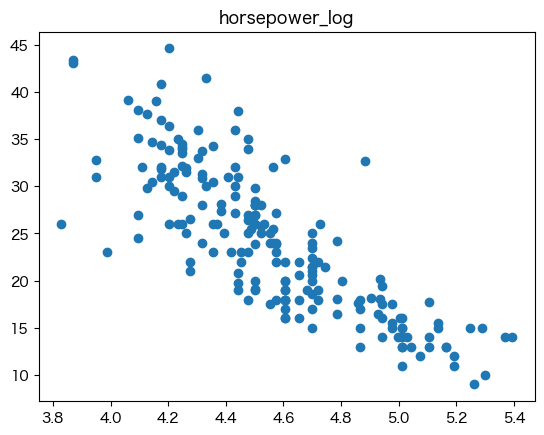

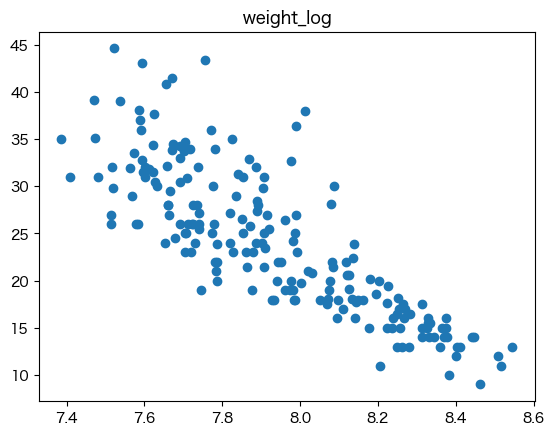

In [112]:
plt.figure(figsize=(5, 5))
for feature in train_df.columns:
    plt.title(feature)
    plt.scatter(data=train_df, x=feature, y='mpg')
    plt.show()

In [113]:
# scikit-learnライブラリからtrain_test_split関数をインポート
from sklearn.model_selection import train_test_split

# idの削除
# train_df = train_df.drop(columns=['id'], axis=1)

# 欠損値を含む行の削除
train_df = train_df.dropna()

# 説明変数と目的変数の取り出し
y = train_df['mpg']
X = train_df[['cylinders','displacement_log','horsepower_log','weight_log','acceleration','origin']] # 'model year','origin', 'car name']]

X = pd.get_dummies(X) # 各説明変数のダミー変数化

# 学習データと評価データに分割
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=32, test_size=0.2)

# X_trainとX_testから行数を取り出し、それぞれ変数X_train_line, X_test_lineに代入し、表示
X_train_line = X_train.shape[0]
X_test_line = X_test.shape[0]
print(X_train_line)
print(X_test_line)

156
39


In [114]:
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import mean_squared_error as MSE

# モデルの箱を準備
lr = LR()

# モデルを学習
lr.fit(X_train, y_train)

# モデルから予測結果を求める
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

# 学習データのRMSEの算出
mse_train = MSE(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)

# 評価データのRMSEの算出
mse_test = MSE(y_test,y_pred_test)
rmse_test = np.sqrt(mse_test)

# 学習および評価データに対するRMSEを表示
print(rmse_train)
print(rmse_test)

3.542802109981216
4.913315589849161


In [122]:
# ダミー化と対数化をする前
# 3.7955089273463627
# 5.191634634719943

# ダミー化と対数化
# 3.542802109981216
# 4.913315589849161

In [116]:
# # から無名の空白を削除して追加
# for fet in train_df.columns:
#     print(fet.replace(' ', '_'))
#     train_df[fet] = fet.replace(' ', '_')

In [117]:
# カラム名の空白をアンダースコアに置き換える
train_df.columns = train_df.columns.str.replace(' ', '_')

In [118]:
train_df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin', 'car_name', 'displacement_log',
       'horsepower_log', 'weight_log'],
      dtype='object')

In [119]:
# scikit-learnライブラリからtrain_test_split関数をインポート
from sklearn.model_selection import train_test_split

# idの削除
# train_df = train_df.drop(columns=['id'], axis=1)

# 欠損値を含む行の削除
train_df = train_df.dropna()

# 説明変数と目的変数の取り出し
y = train_df['mpg']
X = train_df[['cylinders','displacement_log','horsepower_log','weight_log','acceleration','model_year','origin', 'car_name']]

X = pd.get_dummies(X) # 各説明変数のダミー変数化

# 学習データと評価データに分割
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=32, test_size=0.2)

# X_trainとX_testから行数を取り出し、それぞれ変数X_train_line, X_test_lineに代入し、表示
X_train_line = X_train.shape[0]
X_test_line = X_test.shape[0]
print(X_train_line)
print(X_test_line)

156
39


In [123]:
from sklearn.linear_model import LinearRegression as LR
from sklearn.metrics import mean_squared_error as MSE

# モデルの箱を準備
lr = LR()

# モデルを学習
lr.fit(X_train, y_train)

# モデルから予測結果を求める
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

# 学習データのRMSEの算出
mse_train = MSE(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)

# 評価データのRMSEの算出
mse_test = MSE(y_test,y_pred_test)
rmse_test = np.sqrt(mse_test)

# 学習および評価データに対するRMSEを表示
print(rmse_train)
print(rmse_test)

0.6684227565912131
12.088979487407123


In [ ]:
# ダミー化と対数化をする前
# 3.7955089273463627
# 5.191634634719943

# ダミー化と対数化
# 3.542802109981216
# 4.913315589849161

# 特徴量を追加 (過学習している)
# 0.6684227565912131
# 12.088979487407123